In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/user/miniconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [15]:
# Folder containing the import summary CSV
folder_path = "outputs/simulations/"
summary_file = os.path.join(folder_path, "all_import_summary.csv")
tmrca_file = "data/processed/tmrcas_state_formatted.txt"

In [3]:
import_summary_df = pd.read_csv(summary_file)
import_summary_df = import_summary_df.sort_values("median_first_import_day")
import_summary_df.head()

,state,mean_first_import_day,median_first_import_day,earliest_first_import_day,latest_first_import_day,num_files
0,Texas,28.000000,28.0,28,28,360000
1,New Mexico,38.615669,36.0,28,115,360000
2,Kansas,40.351114,38.0,28,130,360000
3,Colorado,42.832083,41.0,28,134,360000
4,Minnesota,43.367761,41.0,28,130,360000


In [16]:
date_of_entry_df = pd.read_csv(tmrca_file, sep = '\t')
date_of_entry_df.head()

,State,dateOfEntry,TMRCA,dateOfEntry_day,TMRCA_day,State_full
0,TX,2024.047896,2024.047896,18,18,Texas
1,NM,2024.126050,2024.144866,47,54,New Mexico
2,KS,2024.149911,2024.160340,55,59,Kansas
3,ID,2024.173785,2024.202230,64,75,Idaho
4,NC,2024.181380,2024.216585,67,80,North Carolina


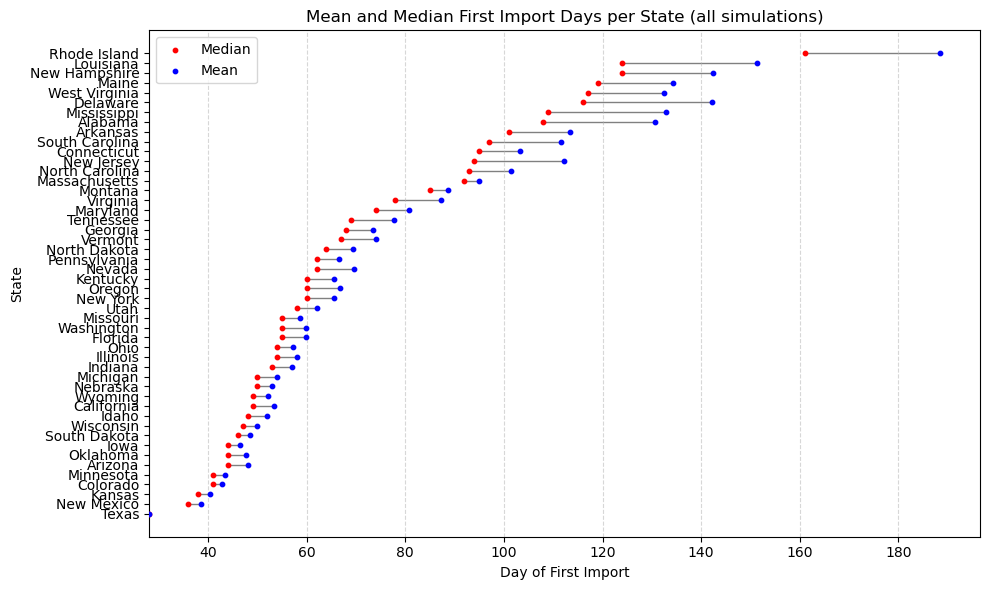

In [18]:
plt.figure(figsize=(10, 6))

# Plot median (red) and mean (blue) for each state
plt.scatter(import_summary_df['median_first_import_day'], import_summary_df['state'], color='red', label='Median', s=10, zorder=5)
plt.scatter(import_summary_df['mean_first_import_day'], import_summary_df['state'], color='blue', label='Mean', s=10, zorder=5)
#plt.scatter(import_summary_df['earliest_first_import_day'], import_summary_df['state'], color='gray', label='Earliest', s=5, zorder=5)
#plt.scatter(import_summary_df['latest_first_import_day'], import_summary_df['state'], color='black', label='Latest', s=5, zorder=5)


# Connect median and mean with horizontal lines
for _, row in import_summary_df.iterrows():
    plt.plot([row['median_first_import_day'], row['mean_first_import_day']],
             [row['state'], row['state']],
             color='gray', lw=1, zorder=1)

plt.xlabel("Day of First Import")
plt.ylabel("State")
plt.title("Mean and Median First Import Days per State (all simulations)")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(left=28)  # start x-axis at day 28
plt.tight_layout()


plt.savefig("outputs/figures/timeline_first_import_all_sim.png", dpi=600)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
for _, row in df.iterrows():
    plt.plot([row['earliest_first_import_day'], row['latest_first_import_day']],
             [row['state'], row['state']], color='skyblue', lw=4)
    plt.scatter(row['median_first_import_day'], row['state'], color='red', zorder=5)
plt.xlabel("Day of First Import")
plt.ylabel("State")
plt.title("Epidemic First Import Window per State")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.xlim(left=28)  # start x-axis from day 28
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "seed48069_mu_c7_beta0.25_alpha1.0_gamma_1.0_timeline_first_import.png"))
plt.show()